# Univariate, Bivariate, and Multivariate Analysis

> 📘 **Instructor Curriculum** — M07 Machine Learning, scikit-learn module.

## What is it?

Before fitting any model, you look at the data. This notebook does that on the
classic **Iris** dataset. The three words in the title only count **how many columns
you look at in one picture**.

| Name | Columns per picture | Question it answers |
|---|---|---|
| **Univariate** | 1 | How is this one column spread out? |
| **Bivariate** | 2 | Do these two columns move together? |
| **Multivariate** | 3 or more | Out of all the pairs, which one separates the classes best? |

## Why do we need it?

A model cannot tell you whether a problem is easy or impossible. A plot can.

If two classes already sit in separate corners of a scatter plot, a simple model will
work. If every class sits on top of the others, no amount of tuning will save you.
Ten minutes of plotting can save a day of tuning.

Backend analogy: this is **reading the payload before writing the parser**. You would
not write a mapper for a Kafka topic without first inspecting a few real messages.
Same idea here, with pictures instead of log lines.

## The flow of this notebook

```text
 load_iris()  →  DataFrame  →  add target  →  split per class
                                                    │
                    ┌───────────────────────────────┼──────────────────────────┐
                    │                               │                          │
             1 column at a time            2 columns at a time         all columns at once
                 plt.plot                      plt.scatter                sns.pairplot
                (univariate)                   (bivariate)               (multivariate)
```

Each step answers the question the step before it could not.


In [2]:
import pandas as pd
from sklearn.datasets import load_iris

## Loading Iris

`load_iris()` does **not** return a DataFrame. It returns a `Bunch` — a dictionary
that also allows dot access. The parts that matter here:

| Attribute | Shape | Contents |
|---|---|---|
| `iris.data` | `(150, 4)` | the four measurements, as floats |
| `iris.target` | `(150,)` | the answer, as integers `0`, `1`, `2` |
| `iris.feature_names` | 4 strings | `'sepal length (cm)'`, `'sepal width (cm)'`, ... |
| `iris.target_names` | 3 strings | `'setosa'`, `'versicolor'`, `'virginica'` |

`iris.data` and `iris.feature_names` are two halves of the same thing, so
`pd.DataFrame(iris.data, columns=iris.feature_names)` glues them back together.

After this cell the table is **4 columns wide**. The answer column is still missing.


In [3]:
iris = load_iris()
table = pd.DataFrame(iris.data,columns=iris.feature_names)
table.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Where do the numbers 0, 1, and 2 come from?

This is the question the whole notebook turns on, so here is the full answer.

### Short answer

**Nothing computed them. They were already sitting in the file.**

`load_iris()` reads a CSV that ships inside scikit-learn itself. In that file the
species column is *already* stored as `0`, `1`, `2`. No encoder ever runs.

### The proof

The file lives at `sklearn/datasets/data/iris.csv`. Its first line is not data — it is
a small header that records the metadata:

```text
150,4,setosa,versicolor,virginica    ← line 1: 150 rows, 4 features, then the 3 label names
5.1,3.5,1.4,0.2,0                    ← line 2:   four measurements, then the label 0
...
7.0,3.2,4.7,1.4,1                    ← line 51:  the first 1 appears here
...
6.3,3.3,6.0,2.5,2                    ← line 101: the first 2 appears here
```

`load_iris()` then does two mechanical things:

1. the last value of every row becomes `iris.target` → `0,0,0,…,1,1,1,…,2,2,2`
2. the three names on line 1 become `iris.target_names` → `['setosa', 'versicolor', 'virginica']`

The rows are stored grouped and in order, which is why row 0 is setosa, row 50 is the
first versicolor, and row 100 is the first virginica.

### The rule that connects the two

> **A label's number is its position in `target_names`.**

`target_names` is a plain array, so index `0` is the first name, index `1` the second,
index `2` the third. That is the entire mapping. It is a lookup, not a calculation:

```text
   iris.target_names  =  [ 'setosa' , 'versicolor' , 'virginica' ]
                            index 0      index 1        index 2
                               ▲            ▲              ▲
                               │            │              │
   iris.target = [ 0,0,0,…,   1,1,1,…,     2,2,2 ]         │
                   └─ 50 rows ┴─ 50 rows ──┴─ 50 rows ─────┘
```

So `iris.target_names[iris.target[0]]` reads as `target_names[0]` → `'setosa'`.
That expression is the decoder. Use it instead of remembering the order.

### Why *this* order and not some other?

The names happen to be alphabetical: **s**etosa, **ve**rsicolor, **vi**rginica.
That is a convention of this dataset, not a law. It matches what `LabelEncoder` would
produce if you encoded the raw strings yourself, because `LabelEncoder` sorts too:

```python
LabelEncoder().fit(['virginica', 'setosa', 'versicolor']).classes_
# array(['setosa', 'versicolor', 'virginica'])   →   0, 1, 2
```

Lean on alphabetical order for Iris if you like, but **never** assume it for a dataset
someone else built. Always read `target_names`.

### ⚠️ The mistake in the cells below

The next few cells split the table using these names:

| Variable in this notebook | Filter | What it actually holds |
|---|---|---|
| `setosa` | `target == 0` | ✅ setosa |
| `virginica` | `target == 1` | ❌ **versicolor** |
| `versicolor` | `target == 2` | ❌ **virginica** |

The last two names are **swapped**. The code runs fine and every plot still draws,
which is exactly what makes this class of bug dangerous. Nothing throws.

The data itself gives it away. Petal length grows steadily across the three species,
so the group with the *largest* petals has to be virginica:

| `target` | rows | mean petal length | true species |
|---|---|---|---|
| `0` | 0–49 | 1.46 cm | setosa |
| `1` | 50–99 | 4.26 cm | versicolor |
| `2` | 100–149 | 5.55 cm | virginica |

The variable named `versicolor` in this notebook holds the 5.55 cm group — that group
is virginica.

**Smallest fix:** swap the two variable names, or stop typing species names by hand
and let `target_names` supply them. The cell after the split does exactly that.


In [19]:
table['target'] = iris.target
table.head(60)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


Adding `iris.target` makes the table **5 columns wide**: 4 inputs and 1 answer, living
in one frame. `(150, 5)` confirms it.

That is fine for *exploring*, which is all this notebook does. It is not fine for
*training*. A model handed the answer column as an input scores 100% and has learned
nothing, so `X` and `y` must be separated before any `fit`.


In [5]:
table.shape

(150, 5)

## Splitting the table per class

`table.loc[table['target'] == 0]` is a **boolean mask**. The inner expression builds a
Series of 150 `True`/`False` values, and `.loc` keeps only the rows where it is `True`.
It is the Pandas version of `stream().filter(row -> row.getTarget() == 0)`.

Each filter returns exactly **50 rows**, because Iris is perfectly balanced —
50 flowers per species.

We split now because the univariate plot below needs one `plt.plot` call per species
in order to get one colour per species.

Read the ⚠️ above before trusting the names on the next two cells.


In [17]:
table['target']==0

0       True
1       True
2       True
3       True
4       True
       ...  
145    False
146    False
147    False
148    False
149    False
Name: target, Length: 150, dtype: bool

In [ ]:
setosa = table.loc[table['target']==0]
setosa

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [8]:
virginica=table.loc[table['target']==1]
virginica

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1
55,5.7,2.8,4.5,1.3,1
56,6.3,3.3,4.7,1.6,1
57,4.9,2.4,3.3,1.0,1
58,6.6,2.9,4.6,1.3,1
59,5.2,2.7,3.9,1.4,1


In [9]:
versicolor=table.loc[table['target']==2]
versicolor

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
101,5.8,2.7,5.1,1.9,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2
105,7.6,3.0,6.6,2.1,2
106,4.9,2.5,4.5,1.7,2
107,7.3,2.9,6.3,1.8,2
108,6.7,2.5,5.8,1.8,2
109,7.2,3.6,6.1,2.5,2


### 💡 Engineering Extension — decode, do not memorise

*Recommended Extension - Not part of instructor curriculum*

Typing species names by hand is what caused the swap above. `target_names` already
knows the answer, so let it do the labelling.

`dict(enumerate(iris.target_names))` turns the array into
`{0: 'setosa', 1: 'versicolor', 2: 'virginica'}`, and `.map()` applies that dictionary
to every value in the `target` column. The printed petal-length means then confirm
the ordering from the data rather than from memory.


In [ ]:
# The decoder ring: a label's POSITION in target_names is its number
for code, name in enumerate(iris.target_names):
    print(code, "->", name)

# Add a readable column, so no plot has to be labelled from memory
table["species"] = table["target"].map(dict(enumerate(iris.target_names)))

print()
print(table.groupby("species")["petal length (cm)"].mean().round(2))


0 -> setosa
1 -> versicolor
2 -> virginica

species
setosa        1.46
versicolor    4.26
virginica     5.55
Name: petal length (cm), dtype: float64


## Plotting

Three libraries, three jobs:

- `matplotlib.pyplot` — the drawing engine.
- `seaborn` — statistical charts built on top of matplotlib. `pairplot` lives here.
- `numpy` — supplies the fake y-values the first plot needs.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1. Univariate analysis — one column at a time

**Goal:** look at `sepal length` on its own, and ask whether that single number can
tell the three species apart.

A single column is 1-dimensional, but a plot needs both an x and a y. The trick here
is to give every point a y of **zero**, so all the points collapse onto one horizontal
line. `np.zeros_like(...)` builds that array of 50 zeros.

```text
  y
  │
0 ┼──■■■■■■──────────■■■■■■■■■■──■■■■■■■■■──
  └──────────────────────────────────────────  x = sepal length (cm)
      setosa          versicolor    virginica
```

`'s'` is the marker style — a **s**quare. Three separate `plt.plot` calls means
matplotlib picks a new colour for each one automatically.

**What to read from it:** the setosa squares sit clearly to the left of everything
else. The other two species overlap heavily. So sepal length **alone** separates
setosa and fails on the rest.

That is the honest conclusion, and it is the reason we add a second column next.
Univariate analysis is not a weak technique — it is just answering a narrower question.


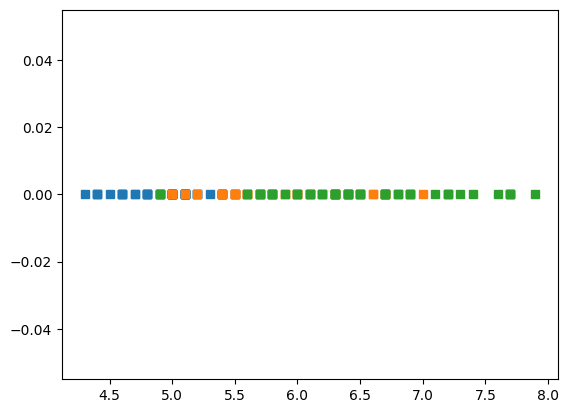

In [12]:
plt.plot(setosa['sepal length (cm)'],np.zeros_like(setosa['sepal length (cm)']),'s')
plt.plot(virginica['sepal length (cm)'],np.zeros_like(virginica['sepal length (cm)']),'s')
plt.plot(versicolor['sepal length (cm)'],np.zeros_like(versicolor['sepal length (cm)']),'s')

These two cells simply print what `np.zeros_like` returned, to confirm the trick.

`zeros_like` copies the **shape and dtype** of whatever you pass it, then fills the
result with zeros — here, 50 floats, all `0.`. The actual measurements in the column
are ignored; only its shape is used.

`np.zeros(50)` would produce the same thing. `zeros_like` is preferred because it
stays correct when the group size changes.


In [ ]:
np.zeros_like(setosa['sepal length (cm)'])

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [14]:
np.zeros_like(virginica['sepal length (cm)'])

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## 2. Bivariate analysis — two columns at a time

**Goal:** put `sepal length` on x and `petal length` on y, then colour each point by
its species.

`c=table['target']` does the colouring. Because `target` holds numbers, matplotlib
runs them through a colormap, so `0`, `1`, and `2` become three different colours.
This is one practical reason a **numeric** target is convenient — passing the string
`'setosa'` to `c=` would raise an error.

Note this cell uses the **whole table**, not the three split frames. One call, one
colour per target value, no manual filtering.

**What to read from it:** setosa is now a completely separate island, far from
everything else. Versicolor and virginica form two clouds that touch along one edge
but mostly sit apart. Two columns achieved what one column could not.


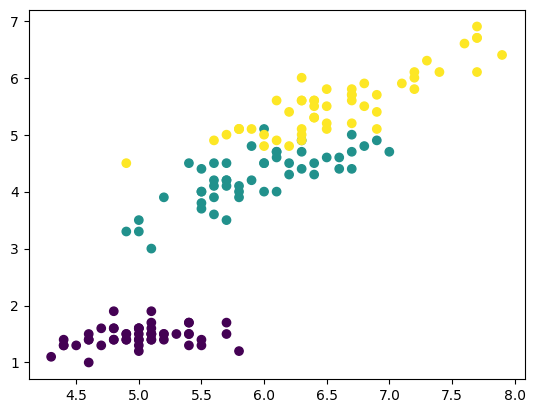

In [15]:
plt.scatter(table['sepal length (cm)'],table['petal length (cm)'],c= table['target'])

## 3. Multivariate analysis — every pair at once

**Goal:** stop guessing which two columns to plot, and plot **all** of them.

`sns.pairplot` builds a 4×4 grid, because the table has 4 feature columns. (`target`
is used as the hue, so seaborn leaves it out of the grid itself.)

```text
               sep len   sep wid   pet len   pet wid
             ┌─────────┬─────────┬─────────┬─────────┐
     sep len │   KDE   │ scatter │ scatter │ scatter │
             ├─────────┼─────────┼─────────┼─────────┤
     sep wid │ scatter │   KDE   │ scatter │ scatter │
             ├─────────┼─────────┼─────────┼─────────┤
     pet len │ scatter │ scatter │   KDE   │ scatter │
             ├─────────┼─────────┼─────────┼─────────┤
     pet wid │ scatter │ scatter │ scatter │   KDE   │
             └─────────┴─────────┴─────────┴─────────┘
                  ▲         ▲
                  │         └── off-diagonal = bivariate, one pair of columns
                  └── diagonal = univariate, the column against itself
```

A column plotted against itself would just be a straight line, so seaborn substitutes
a **density curve** for that single column instead. This means one chart gives you
every univariate view *and* every bivariate view at the same time — steps 1 and 2 of
this notebook, done exhaustively.

### The two arguments

- **`hue="target"`** — colour by species and add a legend. This one argument replaces
  the whole manual three-way split from earlier.
- **`markers=["o", "s", "D"]`** — one marker shape per hue level, in hue order:
  **o**=circle for `0`, **s**=square for `1`, **D**=diamond for `2`. The list length
  must equal the number of hue levels, or seaborn raises an error.

Shapes matter more than they look. Colour alone fails for a colour-blind reader, and
fails again the moment the chart is printed in greyscale. Shape survives both.

**What to read from it:** scan for the panel where the three colours sit furthest
apart. Here it is `petal length` vs `petal width` — three clean groups, barely
touching. The sepal panels are noticeably muddier.

Conclusion: **the petal measurements carry most of the signal.** That is a
feature-selection decision made from a picture, before any model existed.


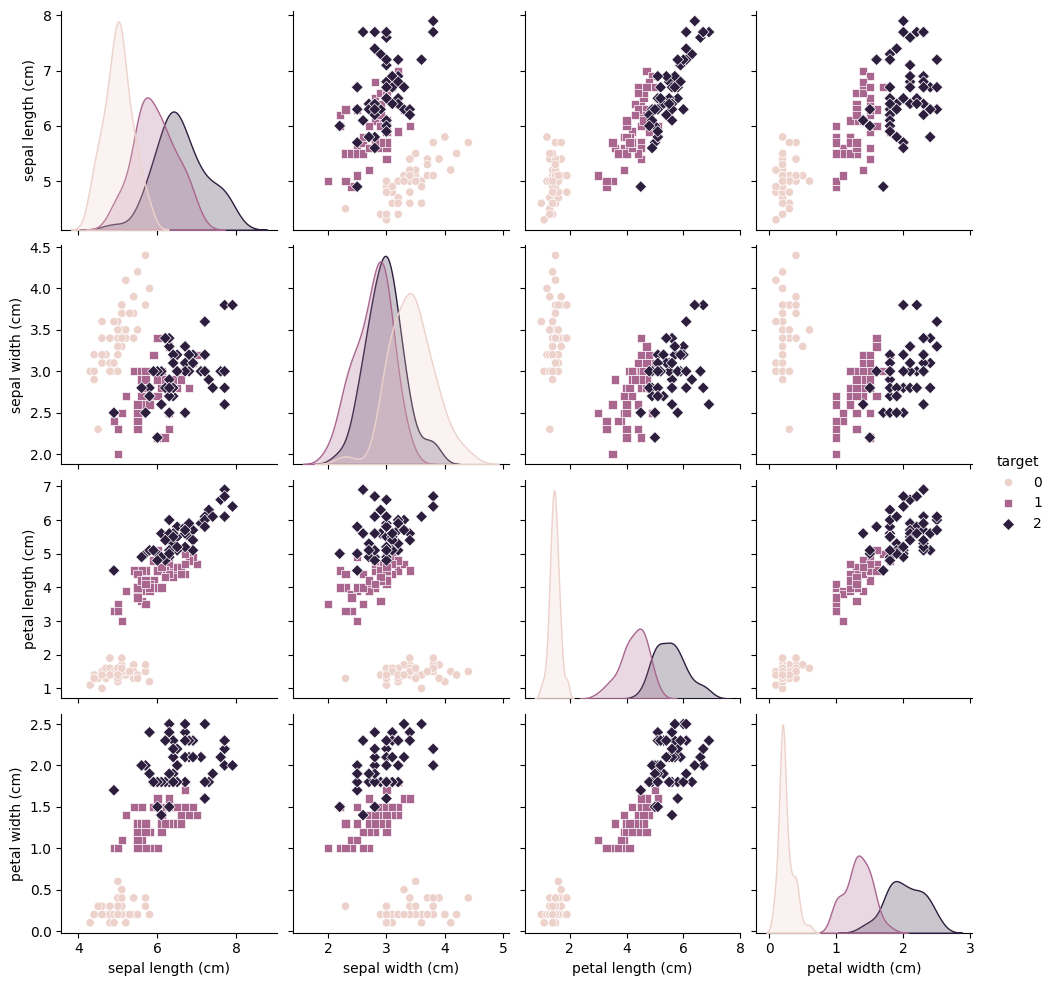

In [16]:
sns.pairplot(table,hue="target", markers=["o", "s", "D"])

## What the three steps concluded

```text
   univariate  (sepal length)      →  separates setosa only
   bivariate   (sepal + petal len) →  separates setosa cleanly, the other two mostly
   multivariate (all 4 columns)    →  petal length + petal width separate all three
```

Each step answered the question the previous one could not, and the last one told us
which columns to keep. That ordering — narrow to wide — is the whole method.

## Common mistakes

1. **Assuming the label order.** `1` is versicolor, not virginica. Read
   `iris.target_names` instead of trusting memory. This notebook got it wrong above,
   and nothing crashed.
2. **Leaving `target` inside `X`.** The table is 5 columns wide now. A model trained
   on all 5 has been handed the answer sheet.
3. **Trusting a univariate plot to prove separability.** Overlap on one axis says
   nothing about a *pair* of axes. Virginica and versicolor overlapped on sepal length
   and separated fine on petal width.
4. **Reading the `pairplot` diagonal as a scatter.** It is a density curve for one
   column, not a relationship between two.
5. **Using colour as the only encoding.** Add `markers` whenever a chart might be
   printed or read by a colour-blind reader.

## Interview view

- *"How do you approach a new classification dataset?"* — Univariate first to see each
  column's spread, bivariate for pairs, `pairplot` to find the strongest pair, and only
  then pick a model.
- *"What is on the pairplot diagonal?"* — The univariate distribution of that one
  column, drawn per hue group.
- *"Where do the Iris target values come from?"* — They ship inside scikit-learn's own
  `iris.csv`, already stored as `0`/`1`/`2`. The number is the index into
  `target_names`. No encoder runs.
- *"Which Iris features matter most?"* — Petal length and petal width. The pairplot
  shows all three species cleanly split on that pair.

## Key takeaway

**If you remember only one thing:** a target number is **a position, not a meaning**.
`iris.target_names[k]` is the only trustworthy way to turn `0`, `1`, `2` back into a
species name.

And the fastest way to find which columns matter is to let `sns.pairplot` draw every
pair, then look for the panel where the colours stop touching.
